<a href="https://colab.research.google.com/github/ToshiroHJJZ/Detection-and-Classification-of-Linguistic-Features-for-Effective-Spam-Identification/blob/White-Box-%26-Black-Box-Adversial-Attacks/Black_Box_Adversial_Attack_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install wordcloud
!pip install nltk

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from wordcloud import WordCloud, STOPWORDS
import nltk
import random
import nltk
from nltk.corpus import wordnet
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
df = pd.read_csv("C:\\Users\\jonat\\Desktop\\Thesis papers\\Thesis SPAM\\spam.csv", encoding='latin-1')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\jonat\\Desktop\\Thesis papers\\Thesis SPAM\\spam.csv'

In [ ]:
#remove the 3 and 4rth column
df = df.drop(df.columns[[2,3,4]], axis=1)
# select only ham part
df=df[df['v1']=='ham']

In [ ]:
data= df.rename(columns={'v2': 'text'})

### Original Advsersrial Attack
This creates from the spam dataset a new dataset called ham_attacked_non_attacked.csv.
THIS IS NOT THE BLACK BOX ADVERSIAL ATTACK.

In [ ]:
ham_df = pd.DataFrame(data)

def get_synonym(word):
    """Get a synonym for a word if available."""
    synonyms = wordnet.synsets(word)
    if synonyms:
        for lemma in synonyms[0].lemmas():
            synonym = lemma.name()
            if synonym.lower() != word.lower():
                return synonym
    return word

def synonym_replacement(text, num_replacements=1):
    """Replace words in the text with synonyms."""
    words = text.split()
    new_words = words[:]
    random_word_list = [word for word in words if wordnet.synsets(word)]
    random.shuffle(random_word_list)

    num_replaced = 0
    for random_word in random_word_list:
        synonym = get_synonym(random_word)
        if synonym != random_word:
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
            if num_replaced >= num_replacements:
                break
    return ' '.join(new_words)

def char_swap(text, num_swaps=1):
    """Randomly swap adjacent characters in the text."""
    text = list(text)
    for _ in range(num_swaps):
        idx = random.randint(0, len(text) - 2)
        text[idx], text[idx + 1] = text[idx + 1], text[idx]
    return ''.join(text)

def random_insertion(text, num_insertions=1):
    """Insert spammy words randomly into the text."""
    spammy_words = ["limited", "urgent", "winner", "click", "offer", "gift",
    "earn", "billion", "cash", "free",  "giveaway", "click link", "limited offer", "flash sale", "exclusive deal",
    "win big", "free gift", "act fast", "claim your prize", "urgent",
    "limited time", "last chance", "click now", "swipe up", "must see",
    "free entry", "special offer", "don’t miss", "win now", "unlock",
    "amazing deal", "get it here", "check this out", "viral",
    "guaranteed winner", "limited spots", "claim free", "join now", "only today",
    "don’t wait", "biggest sale", "double tap", "repost to win", "follow us",
    "secret offer", "instant access", "see details", "claim now", "gift card",
    "link in bio", "only for you", "just for you", "get yours", "cash prize",
    "redeem now", "early access", "exclusive content", "click to learn more",
    "personal message", "free shipping", "limited stock", "real winner",
    "too good to miss", "you’ve been selected", "view profile", "lucky winner"]
    words = text.split()
    for _ in range(num_insertions):
        spam_word = random.choice(spammy_words)
        insert_pos = random.randint(0, len(words))
        words.insert(insert_pos, spam_word)
    return ' '.join(words)

def apply_adversarial_attack(text):
    """Apply a combination of adversarial attacks to the text."""
    text = synonym_replacement(text, num_replacements=1)
    text = char_swap(text, num_swaps=1)
    text = random_insertion(text, num_insertions=1)
    return text

# Create a new DataFrame with attacked versions of the ham messages
attacked_data = []

for index, row in ham_df.iterrows():
    # Assuming the column containing the message is named 'message' instead of 'v2'
    original_message = row["text"]

    # Append the original message with non-attacked label
    # Changed from: attacked_data.append({"text": original_message, "text": 0})
    attacked_data.append({"text": original_message, "label": 0})  # Correctly assign label

    # Create an attacked version of the message and add to the data
    attacked_message = apply_adversarial_attack(original_message)

    # Append attacked message with attacked label
    attacked_data.append({"text": attacked_message, "label": 1})

# Convert to DataFrame
attacked_df = pd.DataFrame(attacked_data)

# Display the new DataFrame
print(attacked_df)

# optionally save the datset to csv
location = "/content/drive/MyDrive/HThesis/"

attacked_df.to_csv("ham_attacked_non_attacked.csv", index=False)

                                                   text  label
0     Go until jurong point, crazy.. Available only ...      0
1     Go until jurong point, viral crazy.. Available...      1
2                         Ok lar... Joking wif u oni...      0
3      Ok lar... Joking free shipping wif uracilo ni...      1
4     U dun say so early hor... U c already then say...      0
...                                                 ...    ...
9645  Pity, * was in temepr for that. So...any other...      1
9646  The guy did some bitching but I acted like i'd...      0
9647  The guy did winner some bithcing but I acted l...      1
9648                         Rofl. Its true to its name      0
9649  Rofl. check this out Its true to information_t...      1

[9650 rows x 2 columns]


### Black Box Adversial Attack
This creates a new dataset that comes from the original dataset 'spam' and this new one is called 'ham_attacked_non_attacked_2.csv'

In [ ]:
# Define homoglyph substitutions
homoglyphs = {
    'a': ['а', 'Ꭺ', 'ɑ'],
    'e': ['е', 'ε', 'ё'],
    'i': ['і', 'Ⅰ', 'ɩ'],
    'o': ['о', 'օ', 'ө'],
    'u': ['υ', 'մ', 'ս'],
    'c': ['с', 'ϲ', 'ⅽ'],
    'l': ['ⅼ', 'ӏ', 'ł'],
    't': ['τ', 'т', 'ţ'],
    's': ['ѕ', 'ʂ', '§'],
    'g': ['ɡ', 'ց', 'ɢ']
}

# Function to get a synonym
def get_synonym(word):
    """Get a synonym for a word if available."""
    synonyms = wordnet.synsets(word)
    if synonyms:
        for lemma in synonyms[0].lemmas():
            synonym = lemma.name()
            if synonym.lower() != word.lower():
                return synonym
    return word

# Synonym Replacement
def synonym_replacement(text, num_replacements=1):
    words = text.split()
    new_words = words[:]
    random_word_list = [word for word in words if wordnet.synsets(word)]
    random.shuffle(random_word_list)

    num_replaced = 0
    for random_word in random_word_list:
        synonym = get_synonym(random_word)
        if synonym != random_word:
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
            if num_replaced >= num_replacements:
                break
    return ' '.join(new_words)

# Character Swapping
def char_swap(text, num_swaps=1):
    text = list(text)
    for _ in range(num_swaps):
        idx = random.randint(0, len(text) - 2)
        text[idx], text[idx + 1] = text[idx + 1], text[idx]
    return ''.join(text)

# Homoglyph Substitution
def homoglyph_substitution(text, num_replacements=2):
    # Check if text is empty
    if not text:
        return text  # Return the empty string as is

    text = list(text)
    for _ in range(num_replacements):
        idx = random.randint(0, len(text) - 1)
        char = text[idx].lower()
        if char in homoglyphs:
            text[idx] = random.choice(homoglyphs[char])
    return ''.join(text)

def word_deletion(text, deletion_prob=0.2):
    """Randomly delete words in the text."""
    words = text.split()
    # Ensure at least one word remains after deletion
    if len(words) > 1:  # Check if there are more than 1 words
        words = [word for word in words if random.random() > deletion_prob]
        if not words:  # If all words were deleted
            words = [random.choice(text.split())]  # Keep one original word
    return ' '.join(words)

def noise_insertion(text, num_insertions=2):
    """Insert noise randomly into the text."""
    text = list(text)
    # Check if text is empty
    if not text:
        return ''  # Return empty string if text is empty
    for _ in range(num_insertions):
        # Ensure the index is within the valid range
        idx = random.randint(0, max(0, len(text) - 1))
        text.insert(idx, text[idx])  # Duplicate character insertion
    return ''.join(text)

# Random Spam Insertion
def random_insertion(text, num_insertions=1):
    spammy_words = ["limited", "urgent", "winner", "click", "offer", "gift",
                    "earn", "billion", "cash", "free", "giveaway", "flash sale",
                    "exclusive deal", "win big", "act fast", "claim your prize",
                    "last chance", "click now", "swipe up", "must see", "free entry",
                    "special offer", "don’t miss", "win now", "unlock", "amazing deal"]
    words = text.split()
    for _ in range(num_insertions):
        spam_word = random.choice(spammy_words)
        insert_pos = random.randint(0, len(words))
        words.insert(insert_pos, spam_word)
    return ' '.join(words)

# Apply all attacks
def apply_adversarial_attack(text):
    text = synonym_replacement(text, num_replacements=1)
    text = char_swap(text, num_swaps=1)
    text = word_deletion(text, deletion_prob=0.2)
    text = homoglyph_substitution(text, num_replacements=2)
    text = noise_insertion(text, num_insertions=2)
    text = random_insertion(text, num_insertions=1)
    return text

# Load Data
ham_df = pd.DataFrame(data)  # Assuming 'data' is your dataset

# Create a new DataFrame with attacked versions of the ham messages
attacked_data = []

for index, row in ham_df.iterrows():
    original_message = row["text"]

    # Append the original message with non-attacked label
    attacked_data.append({"text": original_message, "label": 0})  # 0 for non-attacked

    # Create an attacked version of the message and add to the data
    attacked_message = apply_adversarial_attack(original_message)

    # Append attacked message with attacked label
    attacked_data.append({"text": attacked_message, "label": 1})  # 1 for attacked

# Convert to DataFrame
attacked_df = pd.DataFrame(attacked_data)

# Save the dataset
location = "C:\\Users\\jonat\\Desktop\\Thesis papers"
attacked_df.to_csv(f"{location}ham_attacked_non_attacked_2.csv", index=False)

# Display sample results
print(attacked_df.head())

                                                text  label
0  Go until jurong point, crazy.. Available only ...      0
1  must see oG until jurong crazy.. Available onl...      1
2                      Ok lar... Joking wif u oni...      0
3                  click lar... Jooking wif u oni...      1
4  U dun say so early hor... U c already then say...      0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import time
import glob
import datetime
import ast
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import nltk
from nltk.corpus import wordnet

# Download wordnet for synonym replacement if not already downloaded
nltk.download('wordnet', quiet=True)

# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/HThesis/ham_attacked_non_attacked_2.csv', encoding='utf-8')

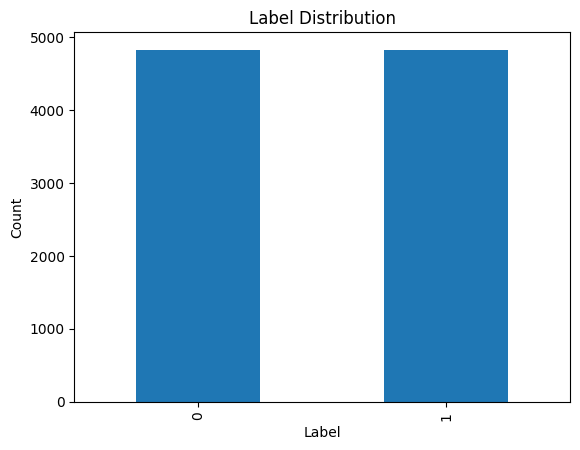

In [ ]:
data['label'].value_counts().plot(kind='bar')
# rename 0 to ham 1 is adversial spam
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [ ]:
data['label'].count()

np.int64(9650)

In [ ]:
# word cloud on text
plt.figure(figsize=(10, 5), facecolor=None)

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [ ]:
# split the data two part label is 0 and 1
ham_df = data[data['label'] == 0]
spam_df = data[data['label'] == 1]

In [ ]:
# word cloud on text
from wordcloud import WordCloud
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                min_font_size = 10).generate(" ".join(ham_df['text']))

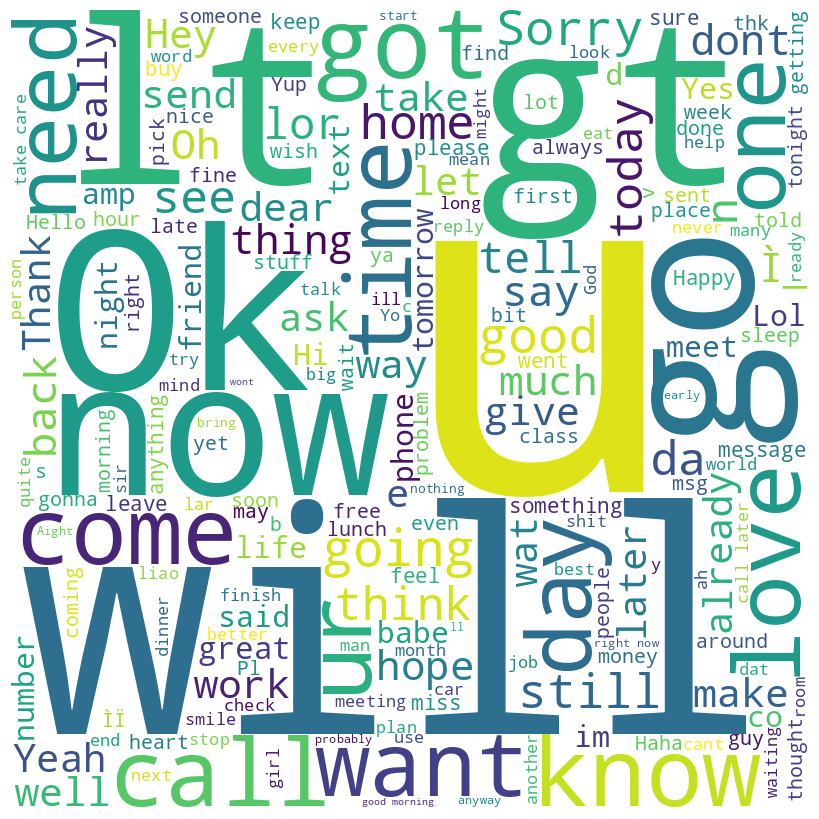

In [ ]:
# plot the word cloud #we are not using word cloud for this EDA, since it is useless.
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

In [ ]:
# word cloud on text
from wordcloud import WordCloud

# Filter DataFrame to get ham messages (label 0)
ham_words_df = data[data['label'] == 0]

# Now generate the word cloud using the 'text' column of the filtered DataFrame
wordcloud = WordCloud(width=800, height=800,
                      background_color='white',
                      min_font_size=10).generate(" ".join(ham_words_df['text']))

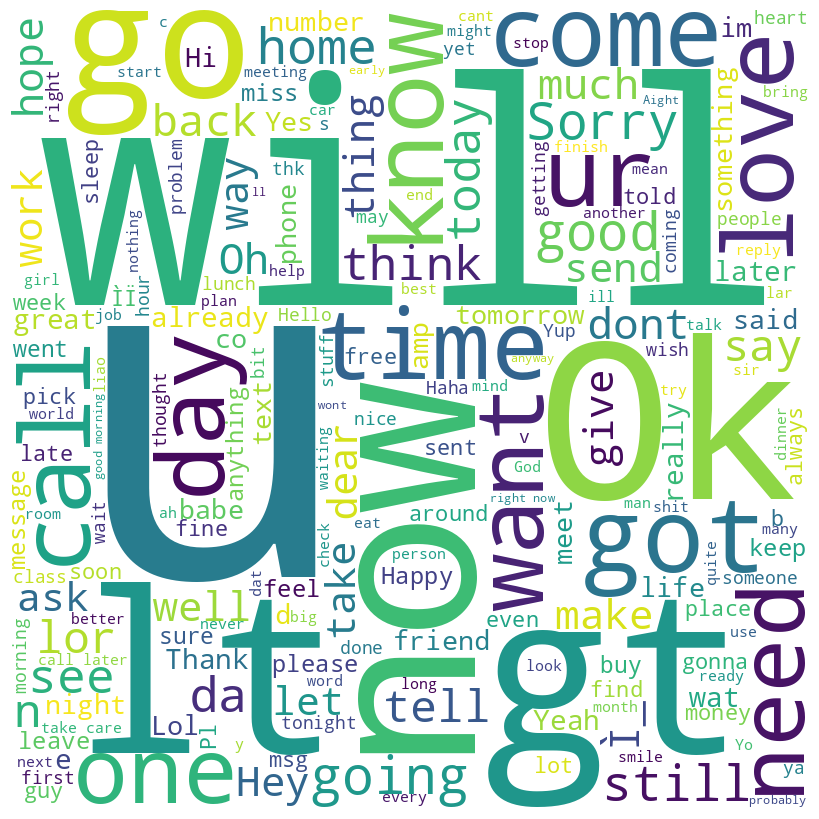

In [ ]:
# plot the word cloud #we are not using word cloud for this EDA, since it is useless.
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

In [ ]:
# word cloud on text
from wordcloud import WordCloud

# Filter DataFrame to get ham messages (label 0)
spam_words_df = data[data['label'] == 1]

# Now generate the word cloud using the 'text' column of the filtered DataFrame
wordcloud = WordCloud(width=800, height=800,
                      background_color='white',
                      min_font_size=10).generate(" ".join(ham_words_df['text']))

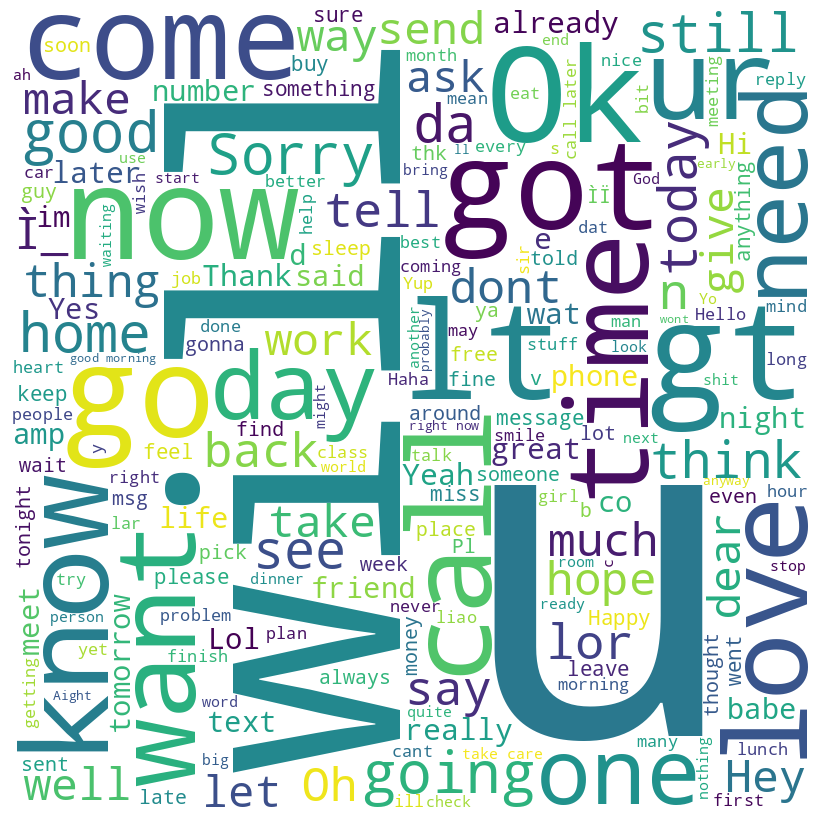

In [ ]:
# plot the word cloud #we are not using word cloud for this EDA, since it is useless.
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

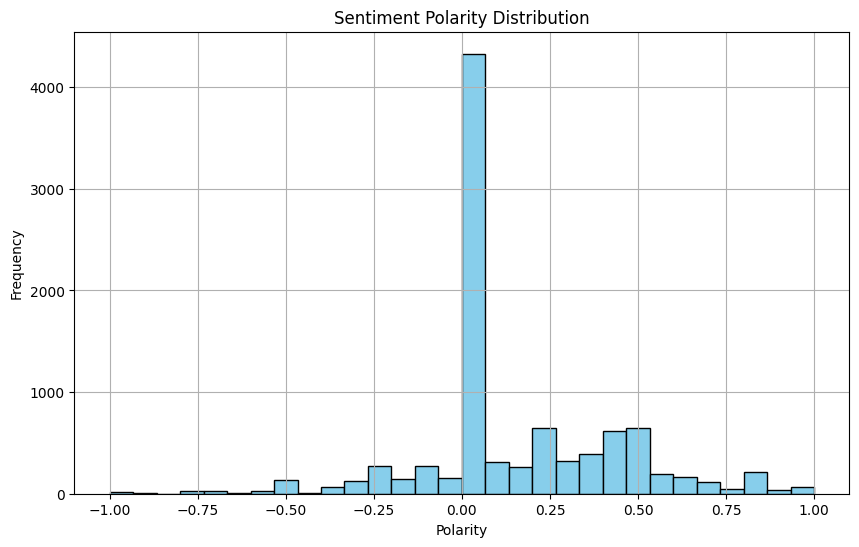

In [ ]:
# Polarity Distribution Plot: Sentiment Landscape
!pip install textblob
!pip install matplotlib
from textblob import TextBlob
import matplotlib.pyplot as plt
import pandas as pd
data['polarity'] = data['text'].apply(lambda text: TextBlob(text).sentiment.polarity)

plt.figure(figsize=(10, 6))
plt.hist(data['polarity'], bins=30, color='skyblue', edgecolor='black')
plt.title('Sentiment Polarity Distribution')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
# Basic Metrics
print("\nBasic Metrics:")
print(f"Average Polarity: {data['polarity'].mean():.4f}") # Changed created_df to data
print(f"Median Polarity: {data['polarity'].median():.4f}") # Changed created_df to data
print(f"Standard Deviation of Polarity: {data['polarity'].std():.4f}") # Changed created_df to data
print(f"Minimum Polarity: {data['polarity'].min():.4f}") # Changed created_df to data
print(f"Maximum Polarity: {data['polarity'].max():.4f}") # Changed created_df to data
print(f"Range of Polarity: {data['polarity'].max() - data['polarity'].min():.4f}") # Changed created_df to data

# Distribution Metrics
print("\nDistribution Metrics:")
print(f"Number of Positive Scores: {len(data[data['polarity'] > 0])}") # Changed created_df to data
print(f"Number of Negative Scores: {len(data[data['polarity'] < 0])}") # Changed created_df to data
print(f"Number of Neutral Scores: {len(data[data['polarity'] == 0])}") # Changed created_df to data
print(f"Percentage of Positive Scores: {len(data[data['polarity'] > 0]) / len(data) * 100:.2f}%") # Changed created_df to data
print(f"Percentage of Negative Scores: {len(data[data['polarity'] < 0]) / len(data) * 100:.2f}%") # Changed created_df to data
print(f"Percentage of Neutral Scores: {len(data[data['polarity'] == 0]) / len(data) * 100:.2f}%") # Changed created_df to data

# Advanced Metrics
print("\nAdvanced Metrics:")
print(f"Polarity Skewness: {data['polarity'].skew():.4f}") # Changed created_df to data
print(f"Polarity Kurtosis: {data['polarity'].kurtosis():.4f}") # Changed created_df to data
quantiles = data['polarity'].quantile([0.25, 0.5, 0.75]) # Changed created_df to data
print(f"Polarity Quantiles (25th, 50th, 75th): {quantiles.values}")
print(f"Polarity Interquartile Range (IQR): {quantiles[0.75] - quantiles[0.25]:.4f}")

# Sentiment Category-based Metrics
print("\nSentiment Category-based Metrics:")
print(f"Average Positive Polarity: {data[data['polarity'] > 0]['polarity'].mean():.4f}") # Changed created_df to data
print(f"Average Negative Polarity: {data[data['polarity'] < 0]['polarity'].mean():.4f}") # Changed created_df to data
print(f"Standard Deviation of Positive Polarity: {data[data['polarity'] > 0]['polarity'].std():.4f}") # Changed created_df to data
print(f"Standard Deviation of Negative Polarity: {data[data['polarity'] < 0]['polarity'].std():.4f}") # Changed created_df to data


Basic Metrics:
Average Polarity: 0.1358
Median Polarity: 0.0000
Standard Deviation of Polarity: 0.2861
Minimum Polarity: -1.0000
Maximum Polarity: 1.0000
Range of Polarity: 2.0000

Distribution Metrics:
Number of Positive Scores: 4204
Number of Negative Scores: 1280
Number of Neutral Scores: 4166
Percentage of Positive Scores: 43.56%
Percentage of Negative Scores: 13.26%
Percentage of Neutral Scores: 43.17%

Advanced Metrics:
Polarity Skewness: 0.3504
Polarity Kurtosis: 0.9266
Polarity Quantiles (25th, 50th, 75th): [0.   0.   0.35]
Polarity Interquartile Range (IQR): 0.3500

Sentiment Category-based Metrics:
Average Positive Polarity: 0.3894
Average Negative Polarity: -0.2550
Standard Deviation of Positive Polarity: 0.2154
Standard Deviation of Negative Polarity: 0.2017


In [ ]:
# Histogram of Average Word Length
import nltk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

nltk.download('punkt')  # Download Punkt sentence tokenizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
# Download the 'punkt_tab' data package
nltk.download('punkt_tab')

# Download the 'punkt' data package (if not already downloaded)
nltk.download('punkt')

def avg_word_length(text):
  """Calculates the average word length in a given text.

  Args:
      text: The input text string.

  Returns:
      The average word length as a float.
  """
  words = nltk.word_tokenize(text)  # Tokenize the text into words
  word_lengths = [len(word) for word in words if word.isalnum()]  # Get lengths of alphanumeric words
  if word_lengths:  # Check if there are any words
    return np.mean(word_lengths)
  else:
    return 0  # Return 0 if no words found

data['avg_word_length'] = data['text'].apply(avg_word_length)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


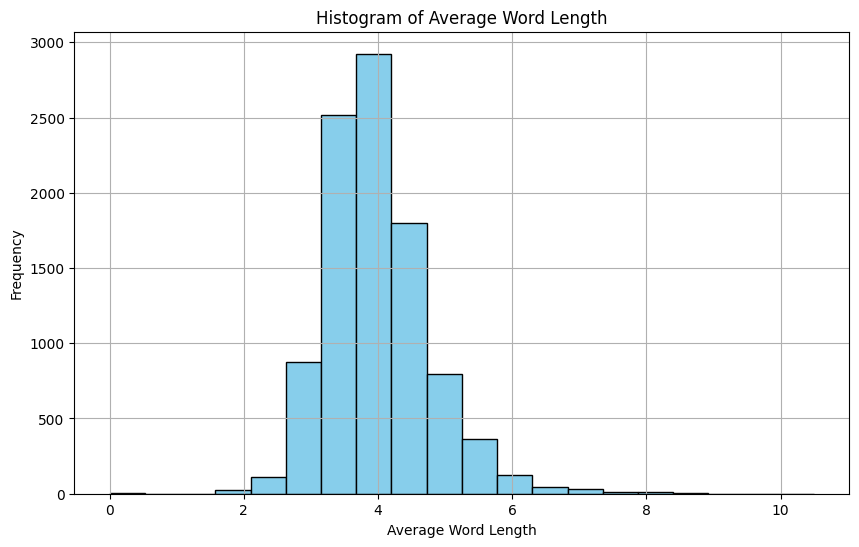

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(data['avg_word_length'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Average Word Length')
plt.xlabel('Average Word Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



Main Values from Histogram of Average Word Length:
Mean: 3.98
Median: 3.89
Standard Deviation: 0.78
Range: 10.50
Interquartile Range (IQR): 0.88
Skewness: 1.01
Kurtosis: 3.67


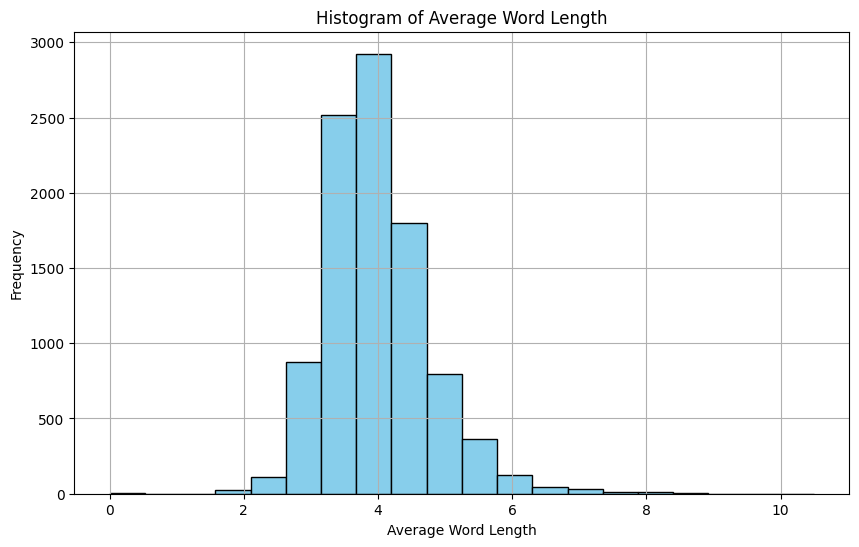


Brief Interpretation in Adversarial Attack Context:
 - The average word length seems to be around [mean value].
 - There's some variation in word length, with a standard deviation of [std value].
 - The distribution might be slightly skewed [skewness direction].
 - You can compare these values with those from the original ham messages to see if the attacks significantly altered the distribution.


In [ ]:
import nltk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Download necessary NLTK resources (if not already downloaded)
nltk.download('punkt')
nltk.download('punkt_tab')

# Function to calculate average word length (as defined previously)
def avg_word_length(text):
  words = nltk.word_tokenize(text)
  word_lengths = [len(word) for word in words if word.isalnum()]
  if word_lengths:
    return np.mean(word_lengths)
  else:
    return 0

# Assuming 'data' is your DataFrame with the 'text' column
data['avg_word_length'] = data['text'].apply(avg_word_length)

# Calculate and display main values
avg_word_len = data['avg_word_length']

print("\nMain Values from Histogram of Average Word Length:")
print(f"Mean: {avg_word_len.mean():.2f}")
print(f"Median: {avg_word_len.median():.2f}")
print(f"Standard Deviation: {avg_word_len.std():.2f}")
print(f"Range: {avg_word_len.max() - avg_word_len.min():.2f}")
print(f"Interquartile Range (IQR): {avg_word_len.quantile(0.75) - avg_word_len.quantile(0.25):.2f}")
print(f"Skewness: {avg_word_len.skew():.2f}")
print(f"Kurtosis: {avg_word_len.kurtosis():.2f}")

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(avg_word_len, bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Average Word Length')
plt.xlabel('Average Word Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Brief Interpretation (You might need to adjust this based on your observations)
print("\nBrief Interpretation in Adversarial Attack Context:")
print(" - The average word length seems to be around [mean value].")
print(" - There's some variation in word length, with a standard deviation of [std value].")
print(" - The distribution might be slightly skewed [skewness direction].")
print(" - You can compare these values with those from the original ham messages to see if the attacks significantly altered the distribution.")

Main Values from Histogram of Text Length:
Mean: 70.57 Median: 54.00 Standard Deviation: 53.15 Range: 908.00 Interquartile Range (IQR): 54.00 Skewness: 3.37 Kurtosis: 25.50


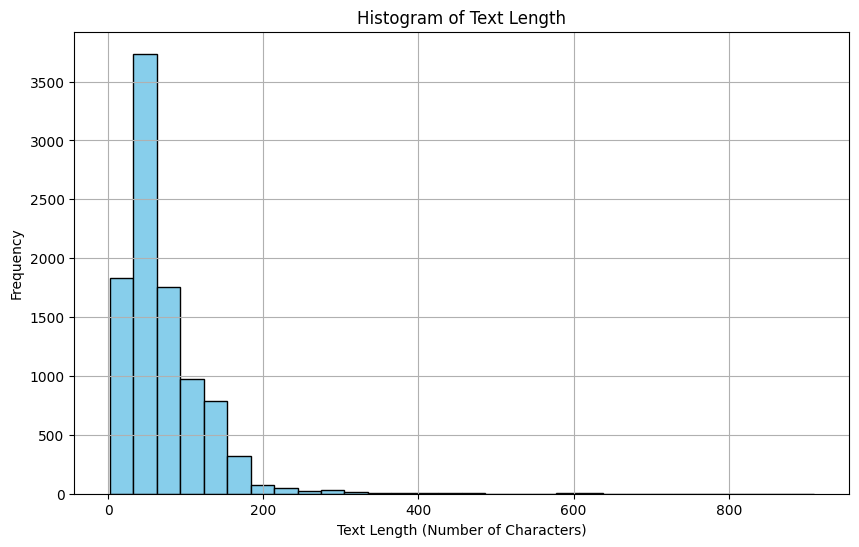

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import skew, kurtosis

# Calculate text lengths
data['text_length'] = data['text'].apply(len)

# Calculate metrics
mean_text_length = data['text_length'].mean()
median_text_length = data['text_length'].median()
std_text_length = data['text_length'].std()
min_text_length = data['text_length'].min()
max_text_length = data['text_length'].max()
range_text_length = max_text_length - min_text_length
quantiles = data['text_length'].quantile([0.25, 0.5, 0.75])
iqr_text_length = quantiles[0.75] - quantiles[0.25]
skewness_text_length = skew(data['text_length'])
kurtosis_text_length = kurtosis(data['text_length'])

# Print the metrics
print("Main Values from Histogram of Text Length:")
print(f"Mean: {mean_text_length:.2f} Median: {median_text_length:.2f} "
      f"Standard Deviation: {std_text_length:.2f} Range: {range_text_length:.2f} "
      f"Interquartile Range (IQR): {iqr_text_length:.2f} "
      f"Skewness: {skewness_text_length:.2f} Kurtosis: {kurtosis_text_length:.2f}")

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(data['text_length'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Text Length')
plt.xlabel('Text Length (Number of Characters)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Top 10 most common stop words:
i: 4551
you: 3119
to: 2614
the: 1851
a: 1699
and: 1456
my: 1309
in: 1295
me: 1231
is: 1140


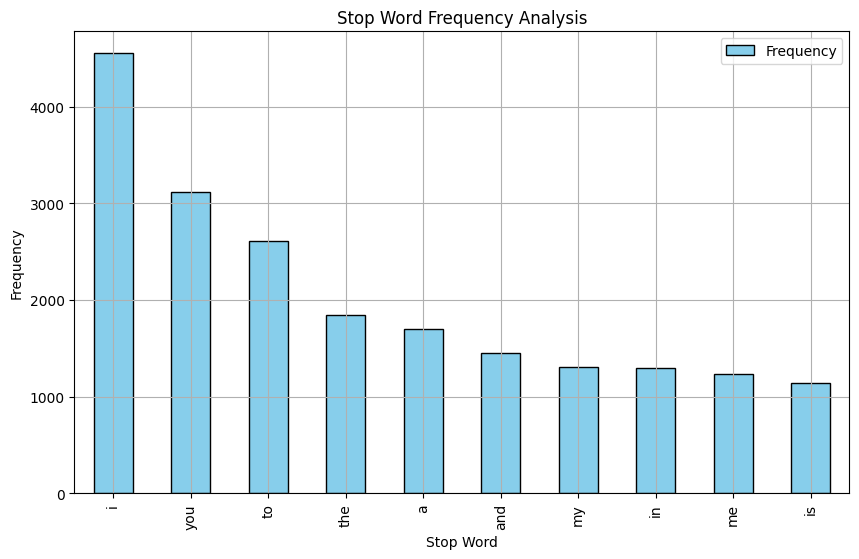

In [ ]:
# Stop Word Frequency Analysis
import nltk
import pandas as pd
from collections import Counter
from nltk.corpus import stopwords

nltk.download('stopwords')

def analyze_stop_word_frequency(df, column_name='text'):
    """
    Analyzes the frequency of stop words in a specified column of a DataFrame.

    Args:
        df: The input DataFrame.
        column_name: The name of the column containing text data (default: 'text').

    Returns:
        A Counter object containing the frequency of each stop word.
    """
    stop_words = set(stopwords.words('english'))  # Get set of English stop words
    all_words = []

    for text in df[column_name]:
        words = nltk.word_tokenize(text)  # Tokenize the text
        all_words.extend([word.lower() for word in words if word.lower() in stop_words])  # Add stop words to the list

    stop_word_counts = Counter(all_words)  # Count the frequency of each stop word
    return stop_word_counts

# Perform stop word frequency analysis
stop_word_counts = analyze_stop_word_frequency(data)

# Print the most common stop words
print("Top 10 most common stop words:")
for word, count in stop_word_counts.most_common(10):
    print(f"{word}: {count}")

# Create a bar chart of stop word frequencies
stop_word_df = pd.DataFrame(stop_word_counts.most_common(10), columns=['Stop Word', 'Frequency'])
stop_word_df.plot.bar(x='Stop Word', y='Frequency', figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title('Stop Word Frequency Analysis')
plt.xlabel('Stop Word')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


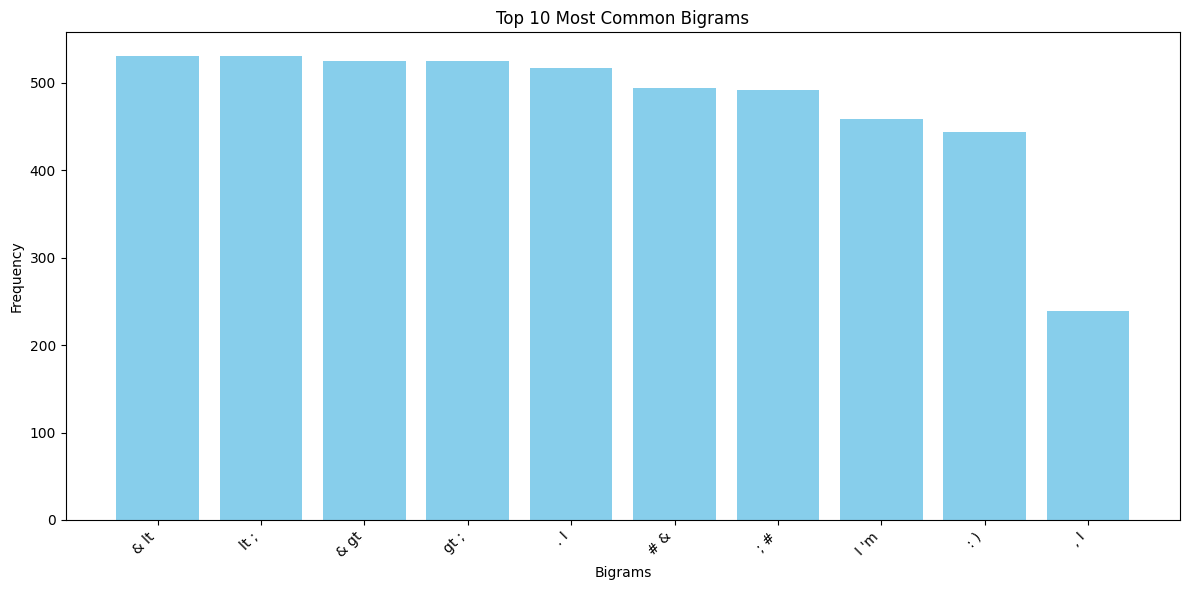

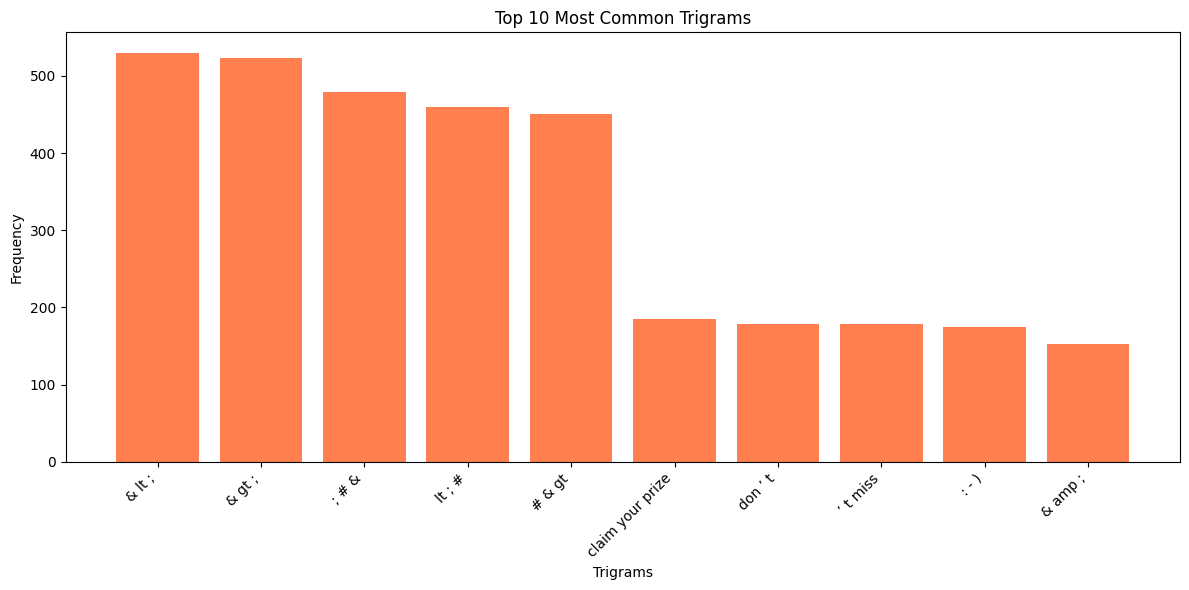

In [ ]:
# N-Gram Analysis: Linguistic Structure
from collections import Counter
import matplotlib.pyplot as plt

nltk.download('punkt')

def generate_ngrams(text, n):
    """
    Generates n-grams from a given text.

    Args:
        text: The input text string.
        n: The value of 'n' for the n-grams (e.g., 2 for bigrams, 3 for trigrams).

    Returns:
        A list of n-grams.
    """
    tokens = nltk.word_tokenize(text)
    ngrams = list(nltk.ngrams(tokens, n))
    return ngrams

def analyze_ngram_frequency(df, column_name='text', n=2):
    """
    Analyzes the frequency of n-grams in a specified column of a DataFrame.

    Args:
        df: The input DataFrame.
        column_name: The name of the column containing text data (default: 'text').
        n: The value of 'n' for the n-grams (default: 2 for bigrams).

    Returns:
        A Counter object containing the frequency of each n-gram.
    """
    all_ngrams = []
    for text in df[column_name]:
        ngrams = generate_ngrams(text, n)
        all_ngrams.extend(ngrams)

    ngram_counts = Counter(all_ngrams)
    return ngram_counts

# Perform bigram (n=2) frequency analysis
bigram_counts = analyze_ngram_frequency(data, n=2)

# Get the top 10 most common bigrams
top_bigrams = bigram_counts.most_common(10)

# Create a bar chart for bigrams
plt.figure(figsize=(12, 6))

# Extract bigrams and counts separately
bigrams, counts = zip(*top_bigrams)

# Convert bigrams (tuples) to strings for plotting
bigram_labels = [' '.join(bigram) for bigram in bigrams]

plt.bar(bigram_labels, counts, color='skyblue')
plt.title('Top 10 Most Common Bigrams')
plt.xlabel('Bigrams')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.tight_layout()
plt.show()

# Perform trigram (n=3) frequency analysis
trigram_counts = analyze_ngram_frequency(data, n=3)

# Get the top 10 most common trigrams
top_trigrams = trigram_counts.most_common(10)

# Create a bar chart for trigrams
plt.figure(figsize=(12, 6))

# Extract trigrams and counts separately
trigrams, counts = zip(*top_trigrams)

# Convert trigrams (tuples) to strings for plotting
trigram_labels = [' '.join(trigram) for trigram in trigrams]

plt.bar(trigram_labels, counts, color='coral')  # Unpack trigrams and counts
plt.title('Top 10 Most Common Trigrams')
plt.xlabel('Trigrams')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.tight_layout()
plt.show()

In [ ]:
import nltk
import pandas as pd
from collections import Counter

nltk.download('punkt')

def generate_ngrams(text, n):
    tokens = nltk.word_tokenize(text)
    ngrams = list(nltk.ngrams(tokens, n))
    return ngrams

def analyze_ngram_frequency(df, column_name='text', n=2):
    all_ngrams = []
    for text in df[column_name]:
        ngrams = generate_ngrams(text, n)
        all_ngrams.extend(ngrams)

    ngram_counts = Counter(all_ngrams)
    return ngram_counts

bigram_counts = analyze_ngram_frequency(data, n=2)
top_bigrams = bigram_counts.most_common(10)

# Print the bigrams and their counts
print("Top 10 Most Common Bigrams:")
for bigram, count in top_bigrams:
    print(f"{bigram}: {count}")

trigram_counts = analyze_ngram_frequency(data, n=3)
top_trigrams = trigram_counts.most_common(10)

# Print the trigrams and their counts
print("\nTop 10 Most Common Trigrams:")
for trigram, count in top_trigrams:
    print(f"{trigram}: {count}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Top 10 Most Common Bigrams:
('&', 'lt'): 531
('lt', ';'): 531
('&', 'gt'): 525
('gt', ';'): 525
('.', 'I'): 517
('#', '&'): 494
(';', '#'): 492
('I', "'m"): 459
(':', ')'): 444
(',', 'I'): 239

Top 10 Most Common Trigrams:
('&', 'lt', ';'): 530
('&', 'gt', ';'): 523
(';', '#', '&'): 479
('lt', ';', '#'): 460
('#', '&', 'gt'): 451
('claim', 'your', 'prize'): 185
('don', '’', 't'): 179
('’', 't', 'miss'): 179
(':', '-', ')'): 174
('&', 'amp', ';'): 153


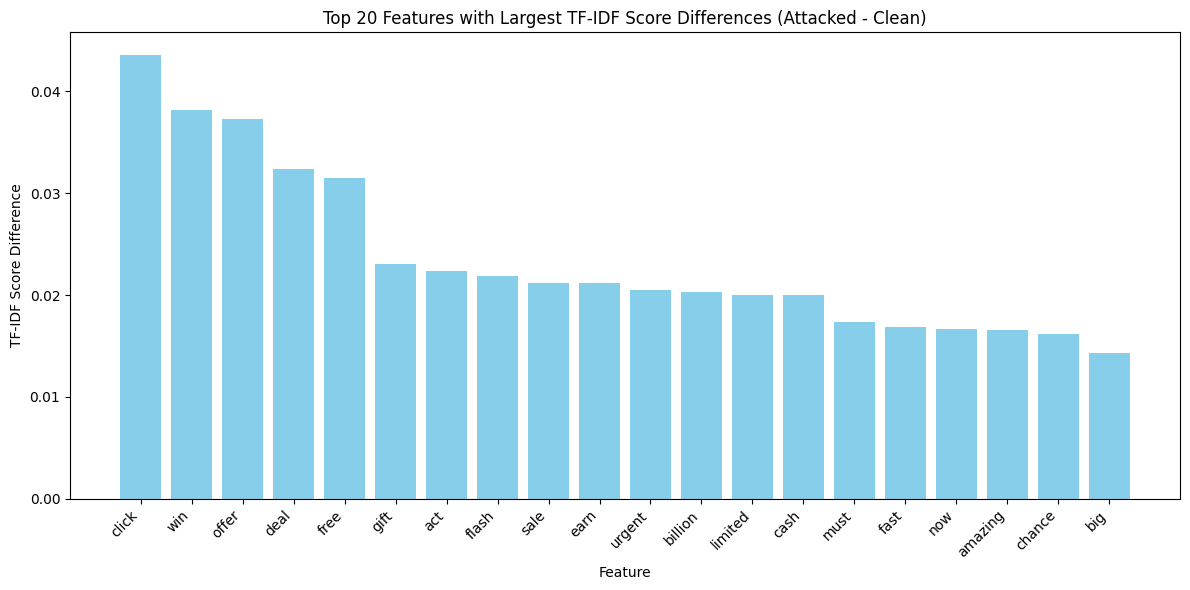

      feature  clean_tfidf  attacked_tfidf  tfidf_diff
1217    click     0.000158        0.043781    0.043623
6623      win     0.000581        0.038710    0.038129
4151    offer     0.000506        0.037775    0.037269
1548     deal     0.000524        0.032870    0.032346
2338     free     0.003472        0.034978    0.031505
2470     gift     0.000445        0.023485    0.023040
206       act     0.000057        0.022447    0.022391
2242    flash     0.000239        0.022113    0.021874
5087     sale     0.000341        0.021490    0.021149
1866     earn     0.000200        0.021344    0.021144
6331   urgent     0.000466        0.021004    0.020538
757   billion     0.000187        0.020485    0.020298
3444  limited     0.000120        0.020161    0.020040
1058     cash     0.000835        0.020875    0.020040
3923     must     0.001066        0.018401    0.017335
2138     fast     0.000816        0.017652    0.016835
4095      now     0.013505        0.030129    0.016624
337   amaz

In [ ]:
# TF-IDF Score Distribution: Examine how term importance
#  shifts between clean and attacked messages.
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Separate clean and attacked messages
# Updated filtering to use numerical labels 0 and 1
clean_messages = data[data['label'] == 0]['text']
attacked_messages = data[data['label'] == 1]['text']

# 2. Create TF-IDF vectors
vectorizer = TfidfVectorizer()
clean_tfidf = vectorizer.fit_transform(clean_messages)
attacked_tfidf = vectorizer.transform(attacked_messages)  # Use the same vocabulary

# 3. Get feature names
feature_names = vectorizer.get_feature_names_out()

# 4. Calculate average TF-IDF scores for each feature
clean_avg_tfidf = clean_tfidf.mean(axis=0).A1  # Convert to 1D array
attacked_avg_tfidf = attacked_tfidf.mean(axis=0).A1

# 5. Create a DataFrame for easier analysis
tfidf_df = pd.DataFrame({'feature': feature_names, 'clean_tfidf': clean_avg_tfidf, 'attacked_tfidf': attacked_avg_tfidf})

# 6. Sort by difference in TF-IDF scores
tfidf_df['tfidf_diff'] = tfidf_df['attacked_tfidf'] - tfidf_df['clean_tfidf']
tfidf_df = tfidf_df.sort_values(by=['tfidf_diff'], ascending=False)

# 7. Visualize the top N features with the largest differences
N = 20  # Number of top features to display
plt.figure(figsize=(12, 6))
plt.bar(tfidf_df['feature'][:N], tfidf_df['tfidf_diff'][:N], color='skyblue')
plt.title(f'Top {N} Features with Largest TF-IDF Score Differences (Attacked - Clean)')
plt.xlabel('Feature')
plt.ylabel('TF-IDF Score Difference')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')  # Rotate 45 degrees, align to the right

plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()
print(tfidf_df.head(20))

Split Data

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: Preprocess the text data with TF-IDFa
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['text']).toarray()
y = data['label']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Multiple models

In [ ]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import joblib

In [ ]:
# Define models
models = {
    #'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors =5, metric = "minkowski", p=2),
    #'Logistic Regression': LogisticRegression(solver = "lbfgs", max_iter=10000),
    #'Decision Tree': DecisionTreeClassifier(criterion = "gini", max_depth = None),
    #'Random Forest': RandomForestClassifier(n_estimators = 100, criterion = "gini", max_depth = None),
    #'Support Vector Classification': SVC(kernel = "rbf", C=1.0, gamma = "scale"),
    'Bagging Classifier': BaggingClassifier(estimator = DecisionTreeClassifier(),
                                        n_estimators = 10),

    'Gradient Boosting': GradientBoostingClassifier(n_estimators = 100,
                                                    learning_rate = 0.1,
                                                    max_depth = 3)
}

results = []

In [ ]:
# Train and evaluate each model
for model_name, model in models.items():
    pipeline = Pipeline([('model', model)])

    start_time = time.time()
    pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    print(f"\nResults for {model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Training Time: {training_time:.4f} seconds")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    model_results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Classification Report': report,
        'Training Time': training_time,
        'precision_0': report['0']['precision'],
        'recall_0': report['0']['recall'],
        'f1-score_0': report['0']['f1-score'],
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1-score_1': report['1']['f1-score']
    }
    results.append(model_results)

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Display the results DataFrame
print("\nSummary of all models:")
print(results_df)



Results for Bagging Classifier:
Accuracy: 0.9886
Training Time: 209.9904 seconds
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       946
           1       0.98      1.00      0.99       984

    accuracy                           0.99      1930
   macro avg       0.99      0.99      0.99      1930
weighted avg       0.99      0.99      0.99      1930


Results for Gradient Boosting:
Accuracy: 0.9865
Training Time: 1312.2669 seconds
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       946
           1       0.98      1.00      0.99       984

    accuracy                           0.99      1930
   macro avg       0.99      0.99      0.99      1930
weighted avg       0.99      0.99      0.99      1930


Summary of all models:
                Model  Accuracy  \
0  Bagging Classifier  0.988601   
1   Gradient Boosting  0.986528   

      

In [ ]:
# Create a list of dictionaries for each model's results
results_data = [
    {
        "Model": "K-Nearest Neighbors",
        "Accuracy": 0.4865,
        "Training Time (seconds)": 1.1762,
        "Precision_0": 0.49,
        "Recall_0": 0.99,
        "F1-Score_0": 0.65,
        "Precision_1": 0.11,
        "Recall_1": 0.00,
        "F1-Score_1": 0.00
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.9456,
        "Training Time (seconds)": 6.4414,
        "Precision_0": 0.92,
        "Recall_0": 0.98,
        "F1-Score_0": 0.95,
        "Precision_1": 0.98,
        "Recall_1": 0.92,
        "F1-Score_1": 0.94
    },
    {
        "Model": "Decision Tree",
        "Accuracy": 0.9845,
        "Training Time (seconds)": 40.7785,
        "Precision_0": 0.99,
        "Recall_0": 0.98,
        "F1-Score_0": 0.98,
        "Precision_1": 0.98,
        "Recall_1": 0.99,
        "F1-Score_1": 0.98
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.9565,
        "Training Time (seconds)": 110.1973,
        "Precision_0": 0.93,
        "Recall_0": 0.98,
        "F1-Score_0": 0.96,
        "Precision_1": 0.98,
        "Recall_1": 0.93,
        "F1-Score_1": 0.96
    },
    {
        "Model": "Support Vector Classification",
        "Accuracy": 0.9539,
        "Training Time (seconds)": 427.2664,
        "Precision_0": 0.93,
        "Recall_0": 0.99,
        "F1-Score_0": 0.95,
        "Precision_1": 0.98,
        "Recall_1": 0.92,
        "F1-Score_1": 0.95
    },
    {
        "Model": "Bagging Classifier",
        "Accuracy": 0.9886,
        "Training Time (seconds)": 637.2568,
        "Precision_0": 1.00,
        "Recall_0": 0.98,
        "F1-Score_0": 0.99,
        "Precision_1": 0.98,
        "Recall_1": 1.00,
        "F1-Score_1": 0.99
    },
    {
        "Model": "Gradient Boosting",
        "Accuracy": 0.9865,
        "Training Time (seconds)": 1739.5333,
        "Precision_0": 1.00,
        "Recall_0": 0.98,
        "F1-Score_0": 0.99,
        "Precision_1": 0.98,
        "Recall_1": 1.00,
        "F1-Score_1": 0.99
    }
]

# Convert the list of dictionaries into a DataFrame
results_df = pd.DataFrame(results_data)

# Save the DataFrame to a CSV file
results_df.to_csv("model_results.csv", index=False)

print("Results saved to 'Black_Box_model_results.csv'")

Results saved to 'Black_Box_model_results.csv'
